<a href="https://colab.research.google.com/github/tofighi/tutorials/blob/master/data-science/Chapter_5_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical Statistics for Data Scientists (Python)
# Chapter 5. Classification
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck

Import required Python packages.

In [1]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.naive_bayes import MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression #, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.metrics import roc_curve, accuracy_score, roc_auc_score

import statsmodels.api as sm

# from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
# from pygam import LinearGAM, s, f, l


# from dmba import classificationSummary

import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

Define paths to data sets. If you don't keep your data in the same directory as the code, adapt the path names.

In [2]:
path = 'https://raw.githubusercontent.com/tofighi/BigData/refs/heads/main/datasets/data-science/'
LOAN3000_CSV = path + 'loan3000.csv'
LOAN_DATA_CSV = path + 'loan_data.csv'

# Naive Bayes
## The Naive Solution

 Explicitly sets the order of categories for the pandas categorical variable, making 'paid off' the first/reference level and 'default' the second.

Why it matters for your Naive Bayes:

Controls which class is the baseline in model output

Ensures predict_proba() columns appear as: [P(paid off), P(default)]

Affects interpretation: higher probability in first column = more likely "paid off"

Without it: Pandas uses alphabetical order ('default', 'paid off'), messing up your probability interpretation.

In [3]:
# 1. LOAD DATA
loan_data = pd.read_csv(LOAN_DATA_CSV) # Loan dataset
# 2. CONVERT TO CATEGORICAL (for proper encoding)
# convert to categorical
loan_data.outcome = loan_data.outcome.astype('category')# Target: 'paid off'/'default'
loan_data.outcome.cat.reorder_categories(['paid off', 'default']) # Set order
loan_data.purpose_ = loan_data.purpose_.astype('category') # e.g., 'small_business'
loan_data.home_ = loan_data.home_.astype('category') # e.g., 'OWN'/'RENT'
loan_data.emp_len_ = loan_data.emp_len_.astype('category') # e.g., '> 1 Year'

# 3. PREPARE FEATURES/TARGET
predictors = ['purpose_', 'home_', 'emp_len_'] # Categorical predictors
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='', dtype=int)
# One-hot encodes: purpose_small_business → [0,1,0,...]
y = loan_data[outcome] # Target labels

# 4. TRAIN NAIVE BAYES
naive_model = MultinomialNB(alpha=0.01, fit_prior=True)
naive_model.fit(X, y) # Learns P(purpose|default), P(home|paid), etc.

# 5. PREDICT SINGLE LOAN (#146)
new_loan = X.loc[146:146, :]  # Extract row 146 as new data
print('predicted class: ', naive_model.predict(new_loan)[0]) # 'paid off' or 'default'

probabilities = pd.DataFrame(naive_model.predict_proba(new_loan),
                             columns=naive_model.classes_)
print('predicted probabilities',)
print(probabilities)
# Output: P(paid off) = , P(default) =  for loan #146

predicted class:  default
predicted probabilities
    default  paid off
0  0.653696  0.346304


## Understanding Continuous Features in Naive Bayes

This section demonstrates how to handle and visualize continuous numerical features, specifically `borrower_score` and `payment_inc_ratio`, within the context of a Naive Bayes classification. While scikit-learn's `MultinomialNB` is for discrete features, `GaussianNB` (and the logic often employed in more general Naive Bayes implementations like the R `NaiveBayes` function) models continuous features by assuming a Gaussian (normal) distribution within each class.

The Python code below calculates and visualizes these class-conditional normal distributions for `borrower_score`, providing insights into how different outcomes ('paid off' vs. 'default') might separate based on this feature's statistical properties (mean and standard deviation).

**Key Steps and Concepts:**

1.  **Class-Conditional Statistics**: We calculate the mean and standard deviation of `borrower_score` for each `outcome` class (`paid off` and `default`). These statistics are fundamental for defining the assumed normal distribution for each class.
2.  **Probability Density Function (PDF) Visualization**: Using these statistics, the code plots the normal probability density functions. This allows for a visual comparison of how the `borrower_score` distributions differ between the two loan outcomes.
3.  **Insights for Naive Bayes**: The visual separation (or overlap) of these distributions directly informs the Naive Bayes model. A greater separation implies that the `borrower_score` is a stronger predictor, as its values are more distinctly associated with one outcome over the other.
4.  **Extension to Other Numerical Features**: The process is also extended to `payment_inc_ratio` by calculating its class-conditional statistics, demonstrating a consistent approach for all continuous numerical predictors.

Borrower Score Statistics by Outcome (Mean and Std Dev):
              mean       std
outcome                     
default   0.463220  0.123360
paid off  0.534793  0.123865


/tmp/ipykernel_3232/1466037425.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_borrower_score = loan_data.groupby('outcome')['borrower_score'].agg(['mean', 'std'])


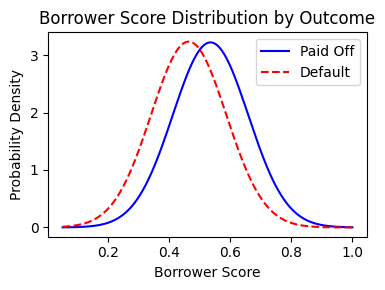


Payment Increment Ratio Statistics by Outcome (Mean and Std Dev):
              mean       std
outcome                     
default   8.770084  4.373793
paid off  7.294367  4.018183


/tmp/ipykernel_3232/1466037425.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_payment_inc_ratio = loan_data.groupby('outcome')['payment_inc_ratio'].agg(['mean', 'std'])


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Assuming 'loan_data' DataFrame is already loaded and 'outcome' is a categorical variable
# from previous cells.
# If not, you would load it like:
# loan_data = pd.read_csv(LOAN_DATA_CSV)
# loan_data.outcome = loan_data.outcome.astype('category').cat.reorder_categories(['paid off', 'default'])

# Calculate statistics (mean and std dev) for 'borrower_score' for each outcome class
# This mimics what `less_naive$table[[1]]` would provide for 'borrower_score'
stats_borrower_score = loan_data.groupby('outcome')['borrower_score'].agg(['mean', 'std'])

print("Borrower Score Statistics by Outcome (Mean and Std Dev):")
print(stats_borrower_score)

# Create the plot similar to the R ggplot + stat_function
fig, ax = plt.subplots(figsize=(4, 3))

# Generate x-values for plotting the normal distribution
x_values = np.linspace(loan_data['borrower_score'].min(), loan_data['borrower_score'].max(), 500)

# Plot for 'paid off' outcome (assuming blue color, solid line)
mean_paid_off = stats_borrower_score.loc['paid off', 'mean']
std_paid_off = stats_borrower_score.loc['paid off', 'std']
ax.plot(x_values, norm.pdf(x_values, mean_paid_off, std_paid_off),
        color='blue', linestyle='-', label='Paid Off')

# Plot for 'default' outcome (assuming red color, dashed line)
mean_default = stats_borrower_score.loc['default', 'mean']
std_default = stats_borrower_score.loc['default', 'std']
ax.plot(x_values, norm.pdf(x_values, mean_default, std_default),
        color='red', linestyle='--', label='Default')

ax.set_xlabel('Borrower Score')
ax.set_ylabel('Probability Density')
ax.set_title('Borrower Score Distribution by Outcome')
ax.legend()

plt.tight_layout()
plt.show()

# Optionally, to get statistics for 'payment_inc_ratio' as well (from less_naive$table[1:2])
stats_payment_inc_ratio = loan_data.groupby('outcome')['payment_inc_ratio'].agg(['mean', 'std'])
print("\nPayment Increment Ratio Statistics by Outcome (Mean and Std Dev):")
print(stats_payment_inc_ratio)


# Discriminant Analysis
## A Simple Example

In [5]:
loan3000 = pd.read_csv(LOAN3000_CSV)
loan3000.outcome = loan3000.outcome.astype('category')

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

loan_lda = LinearDiscriminantAnalysis()
loan_lda.fit(X, y)
print(pd.DataFrame(loan_lda.scalings_, index=X.columns))

                          0
borrower_score     7.175839
payment_inc_ratio -0.099676


In [6]:
pred = pd.DataFrame(loan_lda.predict_proba(loan3000[predictors]),
                    columns=loan_lda.classes_)
print(pred.head())

    default  paid off
0  0.553544  0.446456
1  0.558953  0.441047
2  0.272696  0.727304
3  0.506254  0.493746
4  0.609952  0.390048


### Figure 5.1

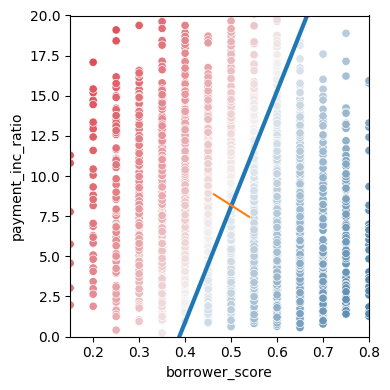

In [7]:
# Use scalings and center of means to determine decision boundary
center = np.mean(loan_lda.means_, axis=0)
slope = - loan_lda.scalings_[0] / loan_lda.scalings_[1]
intercept = center[1] - center[0] * slope

# payment_inc_ratio for borrower_score of 0 and 20
x_0 = (0 - intercept) / slope
x_20 = (20 - intercept) / slope

lda_df = pd.concat([loan3000, pred['default']], axis=1)
lda_df.head()

fig, ax = plt.subplots(figsize=(4, 4))
g = sns.scatterplot(x='borrower_score', y='payment_inc_ratio',
                    hue='default', data=lda_df,
                    palette=sns.diverging_palette(240, 10, n=9, as_cmap=True),
                    ax=ax, legend=False)

ax.set_ylim(0, 20)
ax.set_xlim(0.15, 0.8)
ax.plot((x_0, x_20), (0, 20), linewidth=3)
ax.plot(*loan_lda.means_.transpose())

plt.tight_layout()
plt.show()

# Logistic regression
## Logistic Response Function and Logit

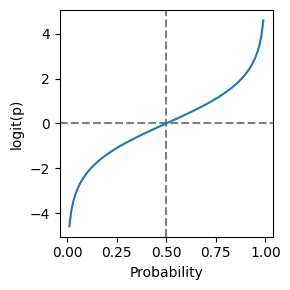

In [8]:
p = np.arange(0.01, 1, 0.01)
df = pd.DataFrame({
    'p': p,
    'logit': np.log(p / (1 - p)),
    'odds': p / (1 - p),
})

fig, ax = plt.subplots(figsize=(3, 3))
ax.axhline(0, color='grey', linestyle='--')
ax.axvline(0.5, color='grey', linestyle='--')
ax.plot(df['p'], df['logit'])
ax.set_xlabel('Probability')
ax.set_ylabel('logit(p)')

plt.tight_layout()
plt.show()

## Logistic Regression and the GLM
The package _scikit-learn_ has a specialised class for `LogisticRegression`. _Statsmodels_ has a more general method based on generalized linear model (GLM).

In [9]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_',
              'borrower_score']
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='',
                   drop_first=True, dtype=int)
y = loan_data[outcome] # .cat.categories

logit_reg = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
logit_reg.fit(X, y)

print('intercept ', logit_reg.intercept_[0])
print('classes', logit_reg.classes_)
pd.DataFrame({'coeff': logit_reg.coef_[0]},
             index=X.columns)

intercept  -1.6380882883923482
classes ['default' 'paid off']


,coeff
payment_inc_ratio,-0.079728
borrower_score,4.611037
debt_consolidation,-0.249342
home_improvement,-0.407614
major_purchase,-0.229376
medical,-0.510087
other,-0.620534
small_business,-1.215662
OWN,-0.048453
RENT,-0.157355


Note that the intercept and coefficients are reversed compared to the R model.

In [10]:
print(loan_data['purpose_'].cat.categories)
print(loan_data['home_'].cat.categories)
print(loan_data['emp_len_'].cat.categories)

Index(['credit_card', 'debt_consolidation', 'home_improvement',
       'major_purchase', 'medical', 'other', 'small_business'],
      dtype='object')
Index(['MORTGAGE', 'OWN', 'RENT'], dtype='object')
Index([' < 1 Year', ' > 1 Year'], dtype='object')


_Not in book_ :
If you have a feature or outcome variable that is ordinal, use the scikit-learn `OrdinalEncoder` to replace the categories (here, 'paid off' and 'default') with numbers. In the below code, we replace 'paid off' with 0 and 'default' with 1. This reverses the order of the predicted classes and as a consequence, the coefficients will be reversed.

In [11]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['paid off', 'default']])
y_enc = enc.fit_transform(loan_data[[outcome]]).ravel()

logit_reg_enc = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
logit_reg_enc.fit(X, y_enc)

print('intercept ', logit_reg_enc.intercept_[0])
print('classes', logit_reg_enc.classes_)
pd.DataFrame({'coeff': logit_reg_enc.coef_[0]},
             index=X.columns)

intercept  1.6378909416318836
classes [0. 1.]


,coeff
payment_inc_ratio,0.079739
borrower_score,-4.612183
debt_consolidation,0.249414
home_improvement,0.407734
major_purchase,0.229710
medical,0.510744
other,0.620800
small_business,1.214936
OWN,0.048211
RENT,0.157288


## Predicted Values from Logistic Regression

In [12]:
pred = pd.DataFrame(logit_reg.predict_log_proba(X),
                    columns=logit_reg.classes_)
print(pred.describe())

            default      paid off
count  45342.000000  45342.000000
mean      -0.757850     -0.760423
std        0.378032      0.390419
min       -2.768873     -3.538865
25%       -0.985728     -0.977164
50%       -0.697366     -0.688946
75%       -0.472209     -0.467076
max       -0.029476     -0.064787


In [13]:
pred = pd.DataFrame(logit_reg.predict_proba(X),
                    columns=logit_reg.classes_)
print(pred.describe())

            default      paid off
count  45342.000000  45342.000000
mean       0.500001      0.499999
std        0.167336      0.167336
min        0.062733      0.029046
25%        0.373167      0.376377
50%        0.497895      0.502105
75%        0.623623      0.626833
max        0.970954      0.937267


## Interpreting the Coefficients and Odds Ratios

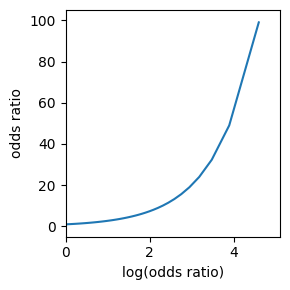

In [14]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(df['logit'], df['odds'])
ax.set_xlabel('log(odds ratio)')
ax.set_ylabel('odds ratio')
ax.set_xlim(0, 5.1)
ax.set_ylim(-5, 105)

plt.tight_layout()
plt.show()

## Assessing the Model
For comparison, here the GLM model using _statsmodels_. This method requires that the outcome is mapped to numbers.

In [15]:
# use GLM (general linear model) with the binomial family to
# fit a logistic regression
y_numbers = [1 if yi == 'default' else 0 for yi in y]
logit_reg_sm = sm.GLM(y_numbers, X.assign(const=1),
                      family=sm.families.Binomial())
logit_result = logit_reg_sm.fit()
print(logit_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                45342
Model:                            GLM   Df Residuals:                    45330
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -28757.
Date:                Wed, 24 Jun 2026   Deviance:                       57515.
Time:                        05:41:43   Pearson chi2:                 4.54e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1112
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
payment_inc_ratio      0.0797      0

Use splines

In [16]:
import statsmodels.formula.api as smf
formula = ('outcome ~ bs(payment_inc_ratio, df=8) + purpose_ + ' +
           'home_ + emp_len_ + bs(borrower_score, df=3)')
model = smf.glm(formula=formula, data=loan_data, family=sm.families.Binomial())
results = model.fit()
print(results.summary())

                             Generalized Linear Model Regression Results                             
Dep. Variable:     ['outcome[default]', 'outcome[paid off]']   No. Observations:                45342
Model:                                                   GLM   Df Residuals:                    45321
Model Family:                                       Binomial   Df Model:                           20
Link Function:                                         Logit   Scale:                          1.0000
Method:                                                 IRLS   Log-Likelihood:                -28731.
Date:                                       Wed, 24 Jun 2026   Deviance:                       57462.
Time:                                               05:41:46   Pearson chi2:                 4.54e+04
No. Iterations:                                            6   Pseudo R-squ. (CS):             0.1122
Covariance Type:                                   nonrobust                      

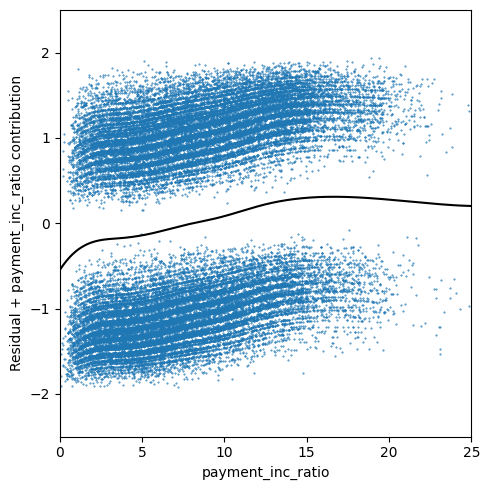

In [17]:
from statsmodels.genmod.generalized_linear_model import GLMResults
def partialResidualPlot(model, df, outcome, feature, fig, ax):
    y_actual = [0 if s == 'default' else 1 for s in df[outcome]]
    y_pred = model.predict(df)
    org_params = model.params.copy()
    zero_params = model.params.copy()
    # set model parametes of other features to 0
    for i, name in enumerate(zero_params.index):
        if feature in name:
            continue
        zero_params.iloc[i] = 0.0
    model.initialize(model.model, zero_params)
    feature_prediction = model.predict(df)
    ypartial = -np.log(1/feature_prediction - 1)
    ypartial = ypartial - np.mean(ypartial)
    model.initialize(model.model, org_params)
    results = pd.DataFrame({
        'feature': df[feature],
        'residual': -2 * (y_actual - y_pred),
        'ypartial': ypartial/ 2,
    })
    results = results.sort_values(by=['feature'])

    ax.scatter(results.feature, results.residual, marker=".", s=72./fig.dpi)
    ax.plot(results.feature, results.ypartial, color='black')
    ax.set_xlabel(feature)
    ax.set_ylabel(f'Residual + {feature} contribution')
    return ax

fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(results, loan_data, 'outcome', 'payment_inc_ratio', fig, ax)
ax.set_xlim(0, 25)
ax.set_ylim(-2.5, 2.5)


plt.tight_layout()
plt.show()

# Evaluating Classification Models
## Confusion Matrix

In [18]:
# Confusion matrix
pred = logit_reg.predict(X)
pred_y = logit_reg.predict(X) == 'default'
true_y = y == 'default'
true_pos = true_y & pred_y
true_neg = ~true_y & ~pred_y
false_pos = ~true_y & pred_y
false_neg = true_y & ~pred_y

conf_mat = pd.DataFrame([[np.sum(true_pos), np.sum(false_neg)], [np.sum(false_pos), np.sum(true_neg)]],
                       index=['Y = default', 'Y = paid off'],
                       columns=['Yhat = default', 'Yhat = paid off'])
print(conf_mat)

              Yhat = default  Yhat = paid off
Y = default            14336             8335
Y = paid off            8148            14523


In [19]:
print(confusion_matrix(y, logit_reg.predict(X)))

[[14336  8335]
 [ 8148 14523]]


The package _dmba_ contains the function `classificationSummary` that prints confusion matrix and accuracy for a classification model.

In [20]:
print(classification_report(y, logit_reg.predict(X)))  # Precision, recall, F1 per class
print(confusion_matrix(y, logit_reg.predict(X)))      # Confusion matrix
print(f"Accuracy: {accuracy_score(y, logit_reg.predict(X)):.3f}")  # Overall accuracy

              precision    recall  f1-score   support

     default       0.64      0.63      0.63     22671
    paid off       0.64      0.64      0.64     22671

    accuracy                           0.64     45342
   macro avg       0.64      0.64      0.64     45342
weighted avg       0.64      0.64      0.64     45342

[[14336  8335]
 [ 8148 14523]]
Accuracy: 0.636


## Precision, Recall, and Specificity
The _scikit-learn_ function `precision_recall_fscore_support` returns
precision, recall, fbeta_score and support.

In [21]:
conf_mat = confusion_matrix(y, logit_reg.predict(X))
print('Precision', conf_mat[0, 0] / sum(conf_mat[:, 0]))
print('Recall', conf_mat[0, 0] / sum(conf_mat[0, :]))
print('Specificity', conf_mat[1, 1] / sum(conf_mat[1, :]))

Precision 0.6376089663760897
Recall 0.6323496978518812
Specificity 0.6405981209474659


In [22]:
precision_recall_fscore_support(y, logit_reg.predict(X),
                                labels=['default', 'paid off'])

(array([0.63760897, 0.63535742]),
 array([0.6323497 , 0.64059812]),
 array([0.63496844, 0.63796701]),
 array([22671, 22671]))

## ROC Curve
The function `roc_curve` in _Scikit-learn_ calculates all the information that is required for plotting a ROC curve.

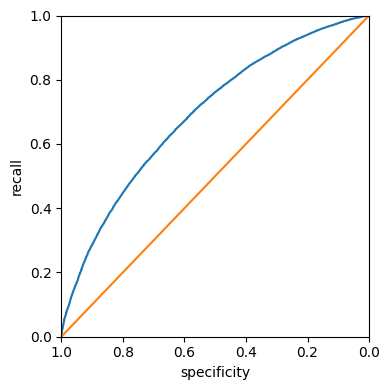

In [23]:
fpr, tpr, thresholds = roc_curve(y, logit_reg.predict_proba(X)[:, 0],
                                 pos_label='default')
roc_df = pd.DataFrame({'recall': tpr, 'specificity': 1 - fpr})

ax = roc_df.plot(x='specificity', y='recall', figsize=(4, 4), legend=False)
ax.set_ylim(0, 1)
ax.set_xlim(1, 0)
ax.plot((1, 0), (0, 1))
ax.set_xlabel('specificity')
ax.set_ylabel('recall')


plt.tight_layout()
plt.show()

## AUC
Accuracy can easily be calculated using the _scikit-learn_ function `accuracy_score`.

In [24]:
print(np.sum(roc_df.recall[:-1] * np.diff(1 - roc_df.specificity)))
print(roc_auc_score([1 if yi == 'default' else 0 for yi in y], logit_reg.predict_proba(X)[:, 0]))

0.691710795288669
0.6917108731135808


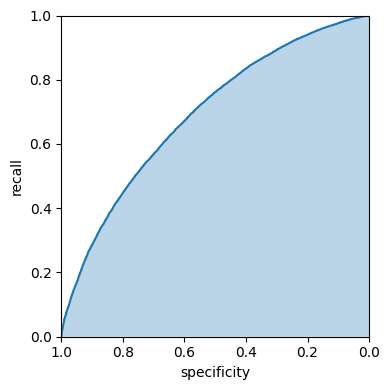

In [25]:
fpr, tpr, thresholds = roc_curve(y, logit_reg.predict_proba(X)[:,0],
                                 pos_label='default')
roc_df = pd.DataFrame({'recall': tpr, 'specificity': 1 - fpr})

ax = roc_df.plot(x='specificity', y='recall', figsize=(4, 4), legend=False)
ax.set_ylim(0, 1)
ax.set_xlim(1, 0)
# ax.plot((1, 0), (0, 1))
ax.set_xlabel('specificity')
ax.set_ylabel('recall')
ax.fill_between(roc_df.specificity, 0, roc_df.recall, alpha=0.3)


plt.tight_layout()
plt.show()